In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [4]:
df = pd.read_csv(r"E:\complaints.csv", low_memory=False, nrows=200000)
print("Sample shape:", df.shape)
print(df.head())


Sample shape: (200000, 18)
  Date received                                            Product  \
0    2020-07-06  Credit reporting, credit repair services, or o...   
1    2025-09-23  Credit reporting or other personal consumer re...   
2    2025-09-22  Credit reporting or other personal consumer re...   
3    2025-09-23  Credit reporting or other personal consumer re...   
4    2025-09-22  Credit reporting or other personal consumer re...   

        Sub-product                                              Issue  \
0  Credit reporting               Incorrect information on your report   
1  Credit reporting               Incorrect information on your report   
2  Credit reporting               Incorrect information on your report   
3  Credit reporting               Incorrect information on your report   
4  Credit reporting  Problem with a company's investigation into an...   

                                           Sub-issue  \
0                Information belongs to someone els

In [5]:
# ================================
# 📌 Section 3: Data Selection & Label Mapping
# ================================

# Keep only relevant columns
df = df[['Product', 'Consumer complaint narrative']].dropna()

# Define category mapping for Task 5
mapping = {
    'Credit reporting, credit repair services, or other personal consumer reports': 0,
    'Debt collection': 1,
    'Consumer Loan': 2,
    'Mortgage': 3
}

# Filter dataset to only keep required categories
df = df[df['Product'].isin(mapping.keys())]

# Map labels
df['label'] = df['Product'].map(mapping)

print("Class distribution:")
print(df['label'].value_counts())
print(df.head())


Class distribution:
label
0    16257
1     7149
3     2669
2      192
Name: count, dtype: int64
                                                Product  \
29                                      Debt collection   
68    Credit reporting, credit repair services, or o...   
743   Credit reporting, credit repair services, or o...   
1118                                    Debt collection   
1266  Credit reporting, credit repair services, or o...   

                           Consumer complaint narrative  label  
29    I am disputing the validity of the debt that i...      1  
68                           These are not my accounts.      0  
743   I wrote three requests, the unverified account...      0  
1118  I reside at creekside XXXX apartments in XXXX....      1  
1266  I have filed a dispute in regards to the incor...      0  


In [6]:
# ================================
# 📌 Section 4: Train-Test Split
# ================================

X = df['Consumer complaint narrative']
y = df['label']

# Split into train & test (stratify keeps same ratio of classes in both sets)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (21013,)
Test size: (5254,)


In [7]:
# ================================
# 📌 Section 5: Text Preprocessing
# ================================

from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text into numerical features
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Train vectorized shape:", X_train_vec.shape)
print("Test vectorized shape:", X_test_vec.shape)


Train vectorized shape: (21013, 5000)
Test vectorized shape: (5254, 5000)


In [8]:
# ================================
# 📌 Section 6: Train Models
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n🔹 Model: {name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))



🔹 Model: Logistic Regression
Accuracy: 0.8877046060144652
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      3252
           1       0.85      0.79      0.82      1430
           2       0.50      0.05      0.10        38
           3       0.91      0.92      0.92       534

    accuracy                           0.89      5254
   macro avg       0.79      0.67      0.69      5254
weighted avg       0.88      0.89      0.88      5254


🔹 Model: Naive Bayes
Accuracy: 0.871145793681005


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      3252
           1       0.84      0.73      0.78      1430
           2       0.00      0.00      0.00        38
           3       0.85      0.93      0.89       534

    accuracy                           0.87      5254
   macro avg       0.64      0.65      0.65      5254
weighted avg       0.86      0.87      0.87      5254


🔹 Model: Linear SVM
Accuracy: 0.8882755995432052
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      3252
           1       0.84      0.80      0.82      1430
           2       0.33      0.08      0.13        38
           3       0.91      0.92      0.91       534

    accuracy                           0.89      5254
   macro avg       0.75      0.68      0.69      5254
weighted avg       0.88      0.89      0.89      5254



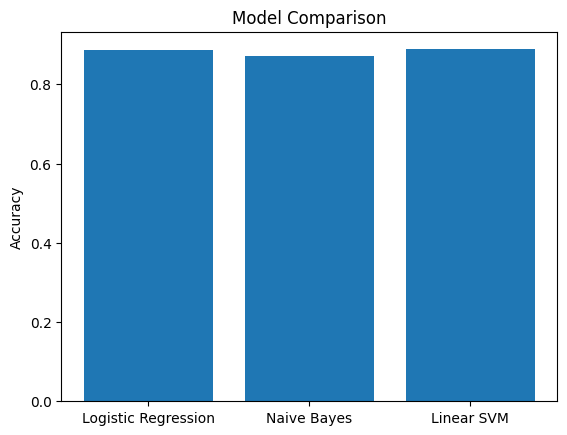

In [9]:
# ================================
# 📌 Section 7: Model Comparison
# ================================
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()


In [10]:
# ================================
# 📌 Section 8: Sample Predictions
# ================================
sample_texts = [
    "I am being harassed by debt collectors every day.",
    "My mortgage company added hidden charges to my loan.",
    "Consumer loan application was rejected unfairly.",
    "Credit reporting agency has false information on my report."
]

sample_vec = vectorizer.transform(sample_texts)

# Pick the best model (SVM usually best)
best_model = LinearSVC().fit(X_train_vec, y_train)
preds = best_model.predict(sample_vec)

reverse_mapping = {v: k for k, v in mapping.items()}
for text, label in zip(sample_texts, preds):
    print(f"Complaint: {text} --> Predicted Category: {reverse_mapping[label]}")


Complaint: I am being harassed by debt collectors every day. --> Predicted Category: Debt collection
Complaint: My mortgage company added hidden charges to my loan. --> Predicted Category: Mortgage
Complaint: Consumer loan application was rejected unfairly. --> Predicted Category: Credit reporting, credit repair services, or other personal consumer reports
Complaint: Credit reporting agency has false information on my report. --> Predicted Category: Credit reporting, credit repair services, or other personal consumer reports
